In [54]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [55]:
load_dotenv()

True

In [56]:
class SubgraphState(TypedDict):
    input_text : str
    translated_text: str

In [57]:
class ParentState(TypedDict):
    topic : str
    eng_response : str
    hin_response : str

# Creating Subgraph First

In [58]:
subgraph_llm = ChatOpenAI(model='gpt-4o')

In [59]:
def translate_to_hindi(state : SubgraphState):
    ''' 
    Translate the given text to hindi language. Do not add any additional contents
    '''
    prompt = f"""
                Translate the following text to Hindi.
                Keep it natural and clear. Do not add extra content.

                Text:
                {state["input_text"]}
            """.strip()
    response = subgraph_llm.invoke(prompt).content

    return {'translated_text' : response}


In [60]:
subgraph_builder = StateGraph(SubgraphState)

subgraph_builder.add_node('translate',translate_to_hindi)

subgraph_builder.add_edge(START,'translate')
subgraph_builder.add_edge('translate',END)

subgraph = subgraph_builder.compile()

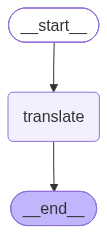

In [61]:
subgraph

In [62]:
response = subgraph.invoke({'input_text' : "I am okay "})

In [63]:
response

{'input_text': 'I am okay ', 'translated_text': 'मैं ठीक हूँ।'}

# Creating Parent Graph

In [64]:
parent_llm = ChatOpenAI()

In [66]:
def generate(state : ParentState):
    '''
    generate a short essay based on the user given topic.
    '''
    response = parent_llm.invoke(state['topic']).content

    return {'eng_response' : response}

def translate(state : ParentState):
    '''
    Translate the given english text to hindi 
    '''
    translated_response = subgraph.invoke({'input_text' : state['eng_response']})['translated_text']

    return {'hin_response' : translated_response}

In [67]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate)
parent_builder.add_node("translate", translate)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

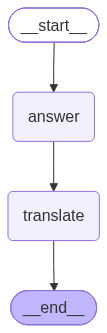

In [68]:
graph = parent_builder.compile()

graph

In [69]:
graph.invoke({'topic': 'What is Gradient Descent, Explain in 50 words.'})

{'topic': 'What is Gradient Descent, Explain in 50 words.',
 'eng_response': 'Gradient Descent is an optimization algorithm used to minimize a function by adjusting its parameters iteratively. It works by calculating the gradient (slope) of the function at each step and moving in the direction that reduces the function output the most. It is commonly used in machine learning for training models.',
 'hin_response': 'Gradient Descent एक अनुकूलन एल्गोरिदम है जिसका उपयोग किसी फंक्शन को न्यूनतम करने के लिए किया जाता है, इसके पैरामीटर को क्रमिक रूप से समायोजित करके। यह प्रत्येक चरण में फंक्शन के ग्रेडिएंट (ढलान) की गणना करके काम करता है और उस दिशा में आगे बढ़ता है जो फंक्शन के आउटपुट को सबसे अधिक कम करता है। इसे आमतौर पर मशीन लर्निंग में मॉडल को प्रशिक्षित करने के लिए उपयोग किया जाता है।'}